# Árvore de decisão — classificação dos estados do jogo da velha

Este experimento utiliza uma **árvore de decisão** para reconhecer os quatro estados
do jogo. Compara as duas representações de entrada com os mesmos conjuntos de treino,
validação e teste dos demais classificadores.

In [1]:
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Configuração do experimento

Comparamos as mesmas amostras em duas representações: **A1**, com as nove casas numéricas
(`b=0`, `x=1`, `o=-1`), e **A2**, com 15 características derivadas. Nesta última, as posições
ocupadas são nove indicadores binários, um por casa. As demais características são contagens
de X e O, alinhamentos com duas marcas, casas vazias e próximo turno hipotético.
A semente 42 identifica a configuração reproduzível do experimento.

In [2]:
SEED = 42
RAIZ = next(
    (pasta for pasta in [Path.cwd(), *Path.cwd().parents]
     if (pasta / "dataset/processado/abordagem_1/treino.csv").is_file()),
    None,
)
if RAIZ is None:
    raise FileNotFoundError("Execute o notebook dentro da pasta deste projeto.")
BASE = RAIZ / "dataset/processado"

CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
abordagens = {"abordagem_1": "A1 (tabuleiro)", "abordagem_2": "A2 (características)"}

## 2. Leitura dos conjuntos preparados

Carregamos os CSVs de treino, validação e teste, separados fisicamente na preparação dos dados.
`X` contém as características e `y` contém o rótulo `estado`. Excluímos `id_tabuleiro`, que serve
para auditoria, e `estado`, que é a resposta a ser prevista, das entradas do classificador.
As divisões são compartilhadas por todos os algoritmos.

In [3]:
dados = {}
for ab in abordagens:
    d = {}
    for conjunto, sufixo in [("treino", "train"), ("validacao", "val"), ("teste", "test")]:
        df = pd.read_csv(f"{BASE}/{ab}/{conjunto}.csv")
        d[f"ids_{sufixo}"] = df["id_tabuleiro"]
        d[f"y_{sufixo}"] = df["estado"].values
        d[f"X_{sufixo}"] = df.drop(columns=["id_tabuleiro", "estado"])
    dados[ab] = d

for ab in abordagens:
    print(abordagens[ab])
    print("  X_train:", dados[ab]["X_train"].shape, " y_train:", dados[ab]["y_train"].shape)
    print("  X_val:  ", dados[ab]["X_val"].shape, " y_val:  ", dados[ab]["y_val"].shape)
    print("  X_test: ", dados[ab]["X_test"].shape, " y_test: ", dados[ab]["y_test"].shape)

A1 (tabuleiro)
  X_train: (560, 9)  y_train: (560,)
  X_val:   (92, 9)  y_val:   (92,)
  X_test:  (93, 9)  y_test:  (93,)
A2 (características)
  X_train: (560, 15)  y_train: (560,)
  X_val:   (92, 15)  y_val:   (92,)
  X_test:  (93, 15)  y_test:  (93,)


In [4]:
# classes em cada conjunto
d = dados["abordagem_1"]
pd.DataFrame({"treino": pd.Series(d["y_train"]).value_counts(),
              "validacao": pd.Series(d["y_val"]).value_counts(),
              "teste": pd.Series(d["y_test"]).value_counts()})

,treino,validacao,teste
Empate,140,2,3
Jogador O venceu,140,30,30
Jogador X venceu,140,30,30
Tem jogo,140,30,30


In [5]:
# Verificar a disjunção dos IDs para evitar o mesmo tabuleiro no treino e na avaliação.
ids_train, ids_val, ids_test = set(d["ids_train"]), set(d["ids_val"]), set(d["ids_test"])
print("treino x validação:", len(ids_train & ids_val))
print("treino x teste:    ", len(ids_train & ids_test))
print("validação x teste: ", len(ids_val & ids_test))
print("linhas do treino:", len(d["ids_train"]), "- tabuleiros distintos:", len(ids_train),
      "(repetições = empates reamostrados no treino)")

treino x validação: 0
treino x teste:     0
validação x teste:  0
linhas do treino: 560 - tabuleiros distintos: 431 (repetições = empates reamostrados no treino)


## 3. Definir as métricas de classificação

- **Acurácia:** proporção de previsões corretas entre todos os exemplos avaliados.
- **Precisão (precision):** entre as previsões de uma classe, proporção de exemplos que pertencem a ela.
- **Sensibilidade (recall):** entre os exemplos reais de uma classe, proporção reconhecida pelo modelo.
- **F1 (F-measure):** média harmônica entre precisão e recall, calculada por `2 × precisão × recall / (precisão + recall)`.

Para precisão, recall e F1, adotamos a média **macro**: calculamos a métrica separadamente
para cada uma das quatro classes e, depois, sua média aritmética. Cada classe recebe o
mesmo peso, inclusive **Empate**, que possui poucos exemplos. O F1 macro é a média dos
F1 por classe; ele não é calculado a partir das médias de precisão e recall.

Quando a divisão de uma métrica é indefinida, `zero_division=0` atribui zero.
A acurácia é calculada sobre o total de exemplos. A seleção dos parâmetros utiliza
F1 macro de validação, enquanto o teste é reservado à avaliação das configurações selecionadas.

Referência: [definição de F1 e média macro no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

In [6]:
def metricas(y_real, y_pred):
    return {"acc": accuracy_score(y_real, y_pred),
            "precision": precision_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "recall": recall_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "f1_macro": f1_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0)}

## 4. Funcionamento da árvore e parâmetros avaliados

A árvore aprende regras de divisão sobre as características, por exemplo: “a quantidade
de casas vazias é menor ou igual a determinado valor?”. Cada divisão forma novos grupos.
Na previsão, o exemplo percorre as regras até uma folha, que determina a classe.
A estrutura pode ser visualizada, favorecendo a interpretação das decisões.

- **Critério (`criterion`):** `gini` e `entropy` avaliam a impureza dos grupos; a divisão busca reduzir a mistura de classes.
- **Profundidade máxima (`max_depth`):** limita os níveis da árvore. A ausência de limite pode favorecer sobreajuste, mas não o determina automaticamente.
- **Tamanho mínimo da folha (`min_samples_leaf`):** exige uma quantidade mínima de registros por folha; valores maiores restringem divisões muito específicas.

Os valores da grade permitem comparar graus de complexidade. A árvore não necessita de
padronização para essas divisões. Usamos `class_weight=None`, pois o treino já foi equilibrado
por reamostragem. As contagens de exemplos nas folhas incluem as repetições desse conjunto.

Referência: [árvores de decisão no scikit-learn](https://scikit-learn.org/stable/modules/tree.html).

In [7]:
# Grade definida antes da avaliação no teste; a ordem determina o último desempate.
lista_criterio = ["gini", "entropy"]            # padrão 'gini'
lista_max_depth = [3, 4, 5, 6, 8, 10, None]     # padrão None (sem limite)
lista_min_leaf = [1, 2, 5]                      # padrão 1

print("Combinações por abordagem:", len(lista_criterio) * len(lista_max_depth) * len(lista_min_leaf))

Combinações por abordagem: 42


In [8]:
def criar_modelo(ab, criterio, max_depth, min_leaf):
    return DecisionTreeClassifier(random_state=SEED,
                                  criterion=criterio,
                                  max_depth=max_depth,
                                  min_samples_leaf=min_leaf,
                                  class_weight=None)   # padrão None. 'balanced' para equilibrar classes

## 5. Seleção dos parâmetros pela validação

Ajustamos cada combinação de parâmetros no conjunto de treino e avaliamos suas previsões
na validação. A seleção prioriza F1 macro de validação; em empate, considera a acurácia.
Se persistir empate, permanece a primeira configuração encontrada na ordem da grade.
Esse último critério é determinístico e não garante a configuração de menor complexidade.
O teste não participa da seleção.

Registramos também o F1 de treino. Uma diferença acentuada em relação à validação pode
indicar **sobreajuste (overfitting)**, isto é, adaptação excessiva aos exemplos de treino.
A diferença deve ser analisada junto com os resultados por classe e as limitações da amostra.

In [9]:
resultados = []   # uma linha para cada combinação testada
melhor = {}       # melhor modelo de cada abordagem (escolhido pela validação)

for ab in abordagens:
    d = dados[ab]
    for criterio in lista_criterio:
        for max_depth in lista_max_depth:
            for min_leaf in lista_min_leaf:
                modelo = criar_modelo(ab, criterio, max_depth, min_leaf)
                modelo.fit(d["X_train"], d["y_train"])
                m_train = metricas(d["y_train"], modelo.predict(d["X_train"]))
                m_val = metricas(d["y_val"], modelo.predict(d["X_val"]))

                resultados.append({"abordagem": abordagens[ab], "criterio": criterio, "max_depth": max_depth,
                                   "min_leaf": min_leaf, "f1_treino": m_train["f1_macro"],
                                   "val_acc": m_val["acc"], "val_f1_macro": m_val["f1_macro"]})

                chave = (m_val["f1_macro"], m_val["acc"])
                if ab not in melhor or chave > melhor[ab]["chave"]:
                    melhor[ab] = {"chave": chave, "f1_treino": m_train["f1_macro"], "modelo": modelo,
                                  "params": {"criterio": criterio, "max_depth": max_depth, "min_leaf": min_leaf}}

resultados = pd.DataFrame(resultados)
print("Combinações testadas:", len(resultados))

Combinações testadas: 84


In [10]:
# melhor configuração de cada abordagem
for ab in abordagens:
    print(abordagens[ab], "->", melhor[ab]["params"], " F1 validação =", round(melhor[ab]["chave"][0], 3))

A1 (tabuleiro) -> {'criterio': 'gini', 'max_depth': 8, 'min_leaf': 1}  F1 validação = 0.519
A2 (características) -> {'criterio': 'gini', 'max_depth': 8, 'min_leaf': 1}  F1 validação = 0.949


In [11]:
# as 5 melhores combinações de cada abordagem (validação)
for ab in abordagens:
    print(abordagens[ab])
    top = resultados[resultados.abordagem == abordagens[ab]].sort_values(["val_f1_macro", "val_acc"], ascending=False)
    display(top.head(5).round(3))

A1 (tabuleiro)


,abordagem,criterio,max_depth,min_leaf,f1_treino,val_acc,val_f1_macro
12,A1 (tabuleiro),gini,8.0,1,0.946,0.674,0.519
16,A1 (tabuleiro),gini,10.0,2,0.914,0.674,0.517
19,A1 (tabuleiro),gini,NaN,2,0.914,0.674,0.517
13,A1 (tabuleiro),gini,8.0,2,0.902,0.652,0.502
30,A1 (tabuleiro),entropy,6.0,1,0.811,0.543,0.482


A2 (características)


,abordagem,criterio,max_depth,min_leaf,f1_treino,val_acc,val_f1_macro
54,A2 (características),gini,8.0,1,0.980,0.935,0.949
51,A2 (características),gini,6.0,1,0.971,0.924,0.941
48,A2 (características),gini,5.0,1,0.960,0.924,0.940
55,A2 (características),gini,8.0,2,0.975,0.913,0.931
58,A2 (características),gini,10.0,2,0.978,0.913,0.931


## 6. Avaliação no teste e medição do custo

O teste avalia as configurações selecionadas pela validação. Seus resultados não são usados
para reajustar os parâmetros. As 20 repetições de ajuste e previsão servem para medir o tempo
médio; não constituem novos experimentos para selecionar modelos.

O tempo de previsão corresponde ao lote completo de 93 tabuleiros. Os dados já estão nas
representações preparadas; leitura dos CSVs e extração das características não são cronometradas.
A comparação de custos deve considerar hardware, versões e condições de execução.

In [12]:
tabela = []
previsoes = {}

for ab in abordagens:
    d = dados[ab]
    modelo = melhor[ab]["modelo"]
    params = melhor[ab]["params"]

    # custo: tempo de treino e de predição
    t0 = time.perf_counter()
    for _ in range(20):
        criar_modelo(ab, **params).fit(d["X_train"], d["y_train"])
    tempo_treino = (time.perf_counter() - t0) / 20 * 1000
    t0 = time.perf_counter()
    for _ in range(20):
        modelo.predict(d["X_test"])
    tempo_pred = (time.perf_counter() - t0) / 20 * 1000

    # Métricas de teste da configuração selecionada, sem novo ajuste de parâmetros.
    previsoes[ab] = modelo.predict(d["X_test"])
    m = metricas(d["y_test"], previsoes[ab])
    tabela.append({"abordagem": abordagens[ab],
                   "acuracia": m["acc"], "precision": m["precision"], "recall": m["recall"], "f1_macro": m["f1_macro"],
                   "gap_treino_val": melhor[ab]["f1_treino"] - melhor[ab]["chave"][0],
                   "tempo_treino_ms": tempo_treino, "tempo_pred_ms": tempo_pred})

tabela = pd.DataFrame(tabela)
tabela.round(3)

,abordagem,acuracia,precision,recall,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.667,0.509,0.517,0.513,0.427,2.295,0.570
1,A2 (características),0.903,0.925,0.925,0.925,0.032,2.078,0.606


## 7. Resultados por classe e matriz de confusão

O relatório apresenta precisão, recall, F1 e suporte, isto é, quantidade de exemplos reais
por classe. As linhas da matriz de confusão representam classes reais e as colunas,
classes previstas. A diagonal reúne os acertos.

Há somente três empates no teste. Por isso, um único erro altera significativamente o recall
dessa classe, e uma pontuação alta deve ser interpretada com essa limitação.

In [13]:
for ab in abordagens:
    print(abordagens[ab])
    print(classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES, zero_division=0))

A1 (tabuleiro)
                  precision    recall  f1-score   support

        Tem jogo       0.60      0.60      0.60        30
Jogador X venceu       0.66      0.63      0.64        30
Jogador O venceu       0.78      0.83      0.81        30
          Empate       0.00      0.00      0.00         3

        accuracy                           0.67        93
       macro avg       0.51      0.52      0.51        93
    weighted avg       0.66      0.67      0.66        93

A2 (características)
                  precision    recall  f1-score   support

        Tem jogo       0.84      0.87      0.85        30
Jogador X venceu       0.89      0.83      0.86        30
Jogador O venceu       0.97      1.00      0.98        30
          Empate       1.00      1.00      1.00         3

        accuracy                           0.90        93
       macro avg       0.92      0.93      0.92        93
    weighted avg       0.90      0.90      0.90        93



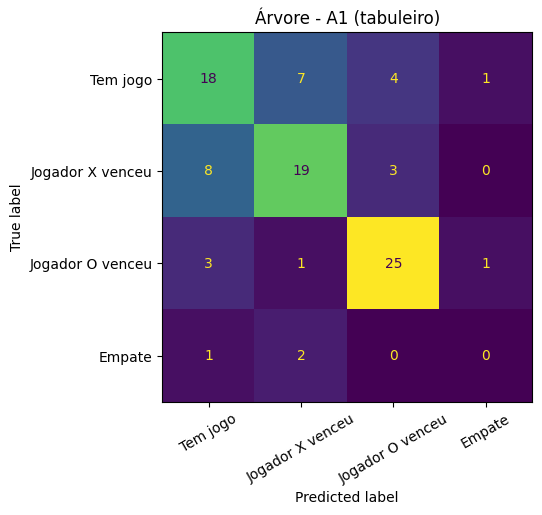

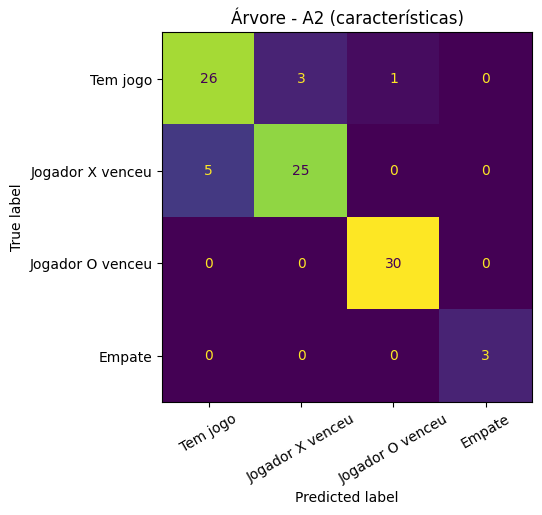

In [14]:
for ab in abordagens:
    resultado = confusion_matrix(dados[ab]["y_test"], previsoes[ab], labels=CLASSES)
    ConfusionMatrixDisplay(resultado, display_labels=CLASSES).plot(xticks_rotation=30, colorbar=False)
    plt.title(f"Árvore - {abordagens[ab]}")
    plt.show()

## 8. Exploração dos resultados em função da profundidade

Para cada profundidade máxima, as curvas mostram separadamente o maior F1 de treino e
o maior F1 de validação entre os critérios e tamanhos mínimos de folha testados. Os máximos
podem provir de configurações diferentes; sua distância não representa necessariamente
a diferença de generalização de um único modelo. Para isso, utilizamos `gap_treino_val`
da configuração selecionada na tabela final.

No eixo horizontal, o valor 12 representa apenas a opção `max_depth=None` (“sem limite”).
Ele não indica que a árvore treinada possui exatamente essa profundidade.

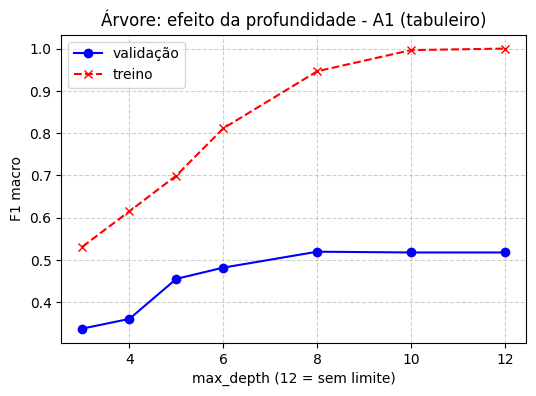

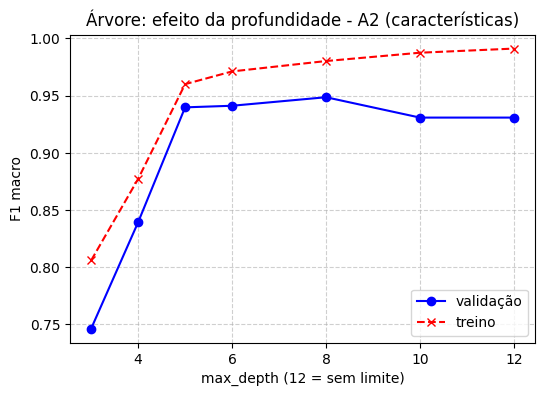

In [15]:
for ab in abordagens:
    s = resultados[resultados.abordagem == abordagens[ab]].copy()
    s["profundidade"] = s["max_depth"].fillna(12)      # 12 apenas posiciona a opção sem limite no gráfico; não é a profundidade observada.
    s = s.groupby("profundidade")[["f1_treino", "val_f1_macro"]].max()
    plt.figure(figsize=(6, 4))
    plt.plot(s.index, s["val_f1_macro"], label="validação", color="blue", marker="o", linestyle="-")
    plt.plot(s.index, s["f1_treino"], label="treino", color="red", marker="x", linestyle="--")
    plt.xlabel("max_depth (12 = sem limite)")
    plt.ylabel("F1 macro")
    plt.title(f"Árvore: efeito da profundidade - {abordagens[ab]}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

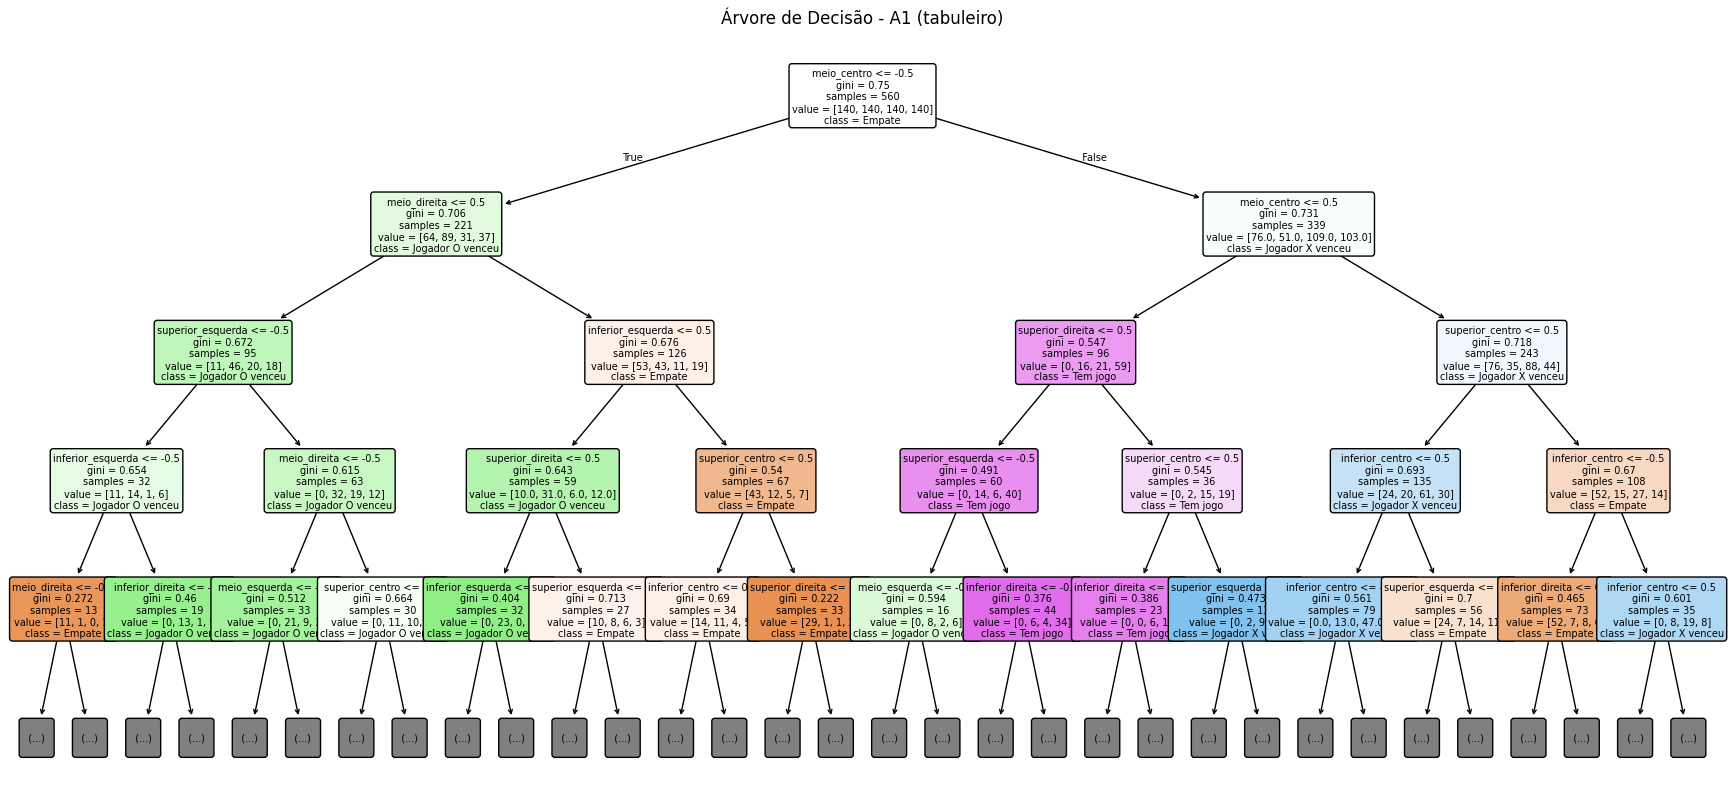

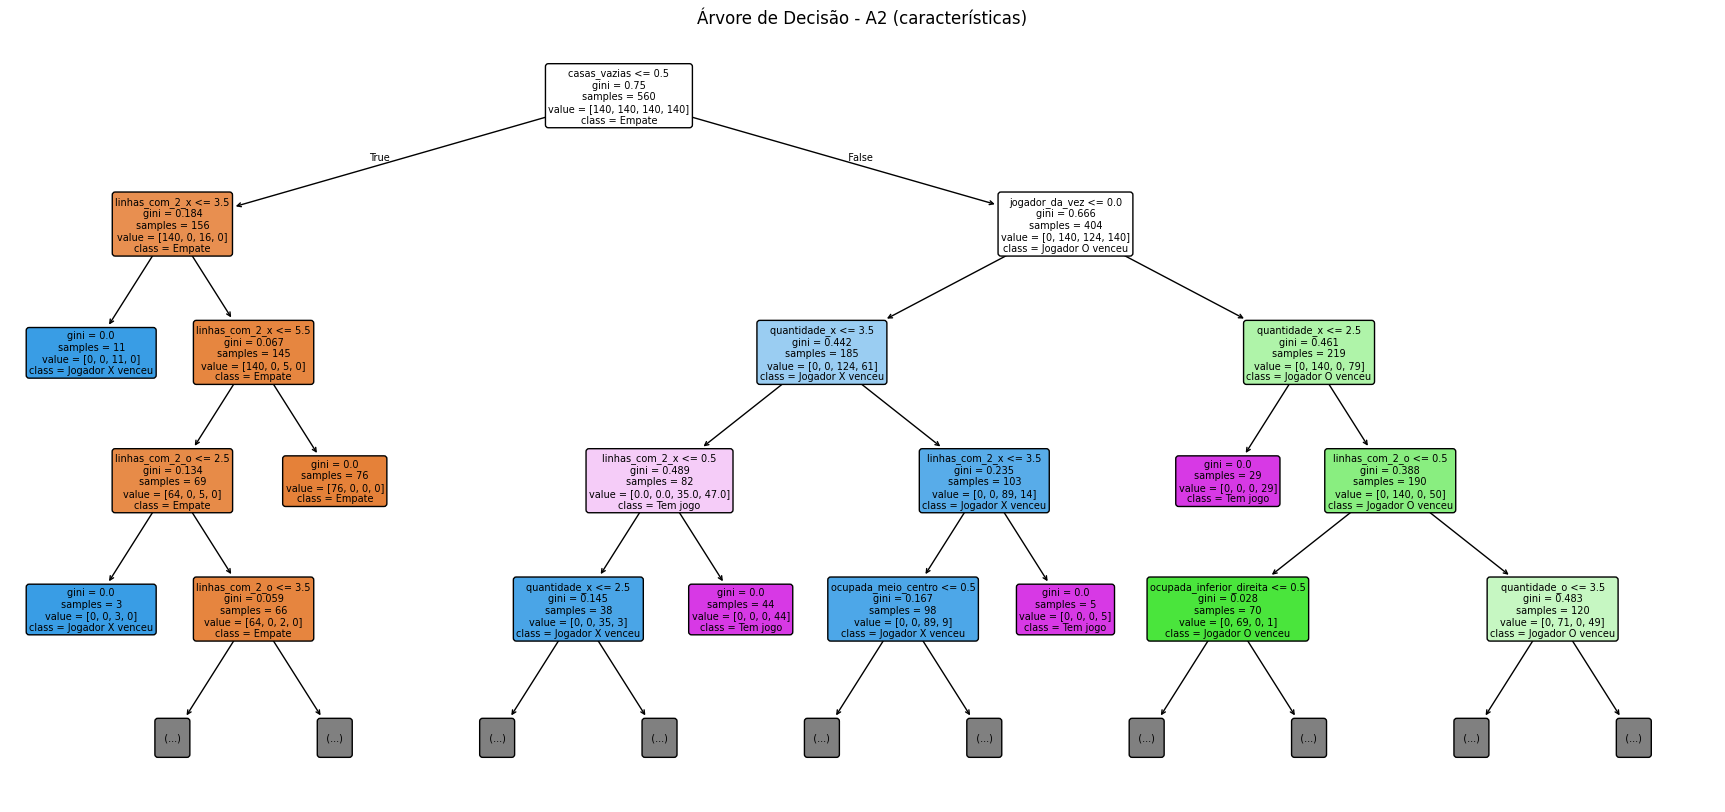

|--- casas_vazias <= 0.50
|   |--- linhas_com_2_x <= 3.50
|   |   |--- class: Jogador X venceu
|   |--- linhas_com_2_x >  3.50
|   |   |--- linhas_com_2_x <= 5.50
|   |   |   |--- linhas_com_2_o <= 2.50
|   |   |   |   |--- class: Jogador X venceu
|   |   |   |--- linhas_com_2_o >  2.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- linhas_com_2_x >  5.50
|   |   |   |--- class: Empate
|--- casas_vazias >  0.50
|   |--- jogador_da_vez <= 0.00
|   |   |--- quantidade_x <= 3.50
|   |   |   |--- linhas_com_2_x <= 0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- linhas_com_2_x >  0.50
|   |   |   |   |--- class: Tem jogo
|   |   |--- quantidade_x >  3.50
|   |   |   |--- linhas_com_2_x <= 3.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- linhas_com_2_x >  3.50
|   |   |   |   |--- class: Tem jogo
|   |--- jogador_da_vez >  0.00
|   |   |--- quantidade_x <= 2.50
|   |   |   |--- class: Tem jogo
|   |   |--- quantidade_x >  2.50
|   |

In [16]:
# desenho da árvore escolhida (até a profundidade 4, para ficar legível)
for ab in abordagens:
    modelo = melhor[ab]["modelo"]
    plt.figure(figsize=(22, 10))
    plot_tree(modelo, filled=True, rounded=True, feature_names=list(dados[ab]["X_train"].columns),
              class_names=list(modelo.classes_), max_depth=4, fontsize=7)
    plt.title(f"Árvore de Decisão - {abordagens[ab]}")
    plt.show()

# regras da árvore da abordagem 2 em texto
print(export_text(melhor["abordagem_2"]["modelo"], feature_names=list(dados["abordagem_2"]["X_train"].columns), max_depth=3))

## 9. Comparação das abordagens A1 e A2

A tabela e o gráfico permitem comparar as métricas de teste, a diferença entre treino e
validação da configuração selecionada e os tempos médios de ajuste e previsão. A análise
conjunta considera qualidade da classificação, possível sobreajuste e custo computacional.

Esses resultados dizem respeito a este algoritmo. A escolha do classificador definitivo
exige reunir os cinco algoritmos e justificar a decisão no relatório.

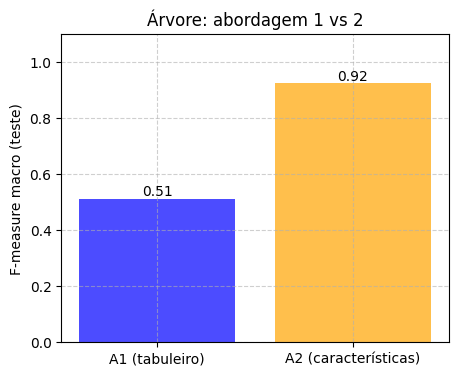

In [17]:
plt.figure(figsize=(5, 4))
plt.bar(tabela["abordagem"], tabela["f1_macro"], color=["blue", "orange"], alpha=0.7)
for i, v in enumerate(tabela["f1_macro"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("F-measure macro (teste)")
plt.title("Árvore: abordagem 1 vs 2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [18]:
tabela[["abordagem", "acuracia", "f1_macro", "gap_treino_val", "tempo_treino_ms", "tempo_pred_ms"]].round(3)

,abordagem,acuracia,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.667,0.513,0.427,2.295,0.570
1,A2 (características),0.903,0.925,0.032,2.078,0.606


## 10. Exportação do modelo para a interface

Escolhemos a representação de entrada pelo **F1 macro de validação** e, em empate,
pela acurácia de validação. Se ambos forem iguais, mantemos a primeira abordagem
na ordem do experimento. O teste não participa dessa escolha.

Salvamos o modelo já ajustado somente no treino, suas configurações, os resultados
da busca e as previsões de teste da abordagem escolhida. Quando o modelo possui
padronização, o `Pipeline` preserva o padronizador ajustado no treino. A exportação
não realiza um novo ajuste.

Os metadados registram a versão do scikit-learn, as colunas de entrada e os hashes
dos CSVs utilizados. Assim, a interface carrega a mesma representação e o mesmo
modelo do experimento, sem treinar durante as partidas. Cada previsão pode ser
comparada ao registro de teste exportado.

O Codex auxiliou na inclusão desta etapa de exportação e na integração com a interface.


In [19]:
import hashlib
import json
import platform

import joblib
import sklearn

ab_escolhida = max(abordagens, key=lambda ab: melhor[ab]["chave"])
modelo_exportado = melhor[ab_escolhida]["modelo"]
PASTA_RESULTADOS = BASE / "arvoreDecisao" / "resultados"
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

# A escolha acima utiliza somente validação; estas previsões servem para auditoria.
d_exportado = dados[ab_escolhida]
previsoes_exportadas = modelo_exportado.predict(d_exportado["X_test"])
pd.DataFrame({
    "abordagem": ab_escolhida,
    "id_tabuleiro": d_exportado["ids_test"].to_numpy(),
    "estado_real": d_exportado["y_test"],
    "estado_previsto": previsoes_exportadas,
    "acertou": d_exportado["y_test"] == previsoes_exportadas,
}).to_csv(PASTA_RESULTADOS / "previsoes_teste.csv", index=False)
resultados.to_csv(PASTA_RESULTADOS / "busca_validacao.csv", index=False)

arquivos_entrada = [
    BASE / ab / f"{conjunto}.csv"
    for ab in abordagens
    for conjunto in ["treino", "validacao", "teste"]
]
resumo = {
    "algoritmo": "Árvore de decisão", "semente": SEED,
    "versoes": {"python": platform.python_version(), "scikit_learn": sklearn.__version__,
                "pandas": pd.__version__, "joblib": joblib.__version__},
    "classes": CLASSES,
    "criterio_selecao_configuracao": "F1 macro de validação; acurácia; primeira configuração da grade",
    "criterio_selecao_abordagem": "F1 macro de validação; acurácia; primeira abordagem",
    "configuracoes_testadas": len(resultados),
    "abordagem_escolhida_pela_validacao": ab_escolhida,
    "configuracoes_selecionadas": {ab: info["params"] for ab, info in melhor.items()},
    "metricas_validacao": {
        ab: {"f1_macro": info["chave"][0], "acuracia": info["chave"][1]}
        for ab, info in melhor.items()
    },
    "features_modelo_exportado": list(d_exportado["X_train"].columns),
    "ordem_classes_modelo": list(map(str, modelo_exportado.classes_)),
    "metricas_teste_modelo_exportado": metricas(d_exportado["y_test"], previsoes_exportadas),
    "csvs_entrada_sha256": {
        str(caminho.relative_to(RAIZ)): hashlib.sha256(caminho.read_bytes()).hexdigest()
        for caminho in arquivos_entrada
    },
}
(PASTA_RESULTADOS / "resumo_experimento.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2) + "\n", encoding="utf-8",
)
joblib.dump(modelo_exportado, PASTA_RESULTADOS / "modelo_arvore.joblib", compress=3)

print("Abordagem exportada:", abordagens[ab_escolhida])
print("Configuração:", melhor[ab_escolhida]["params"])
print("F1 macro de validação:", round(melhor[ab_escolhida]["chave"][0], 6))
print("Arquivos salvos em:", PASTA_RESULTADOS.relative_to(RAIZ))


Abordagem exportada: A2 (características)
Configuração: {'criterio': 'gini', 'max_depth': 8, 'min_leaf': 1}
F1 macro de validação: 0.948533
Arquivos salvos em: dataset/processado/arvoreDecisao/resultados
